# Comparación reproducible: PaySim vs IBM AML HI-Small
**José Auyón · C1: ingeniería de datos · CC3092**

Este notebook documenta la evidencia usada para proponer IBM HI-Small como fuente de secuencias. Ejecuta el perfilado de los **CSV completos**, compara la disponibilidad de historiales y reproduce el muestreo de 50,000 remitentes con recorte a 64 operaciones.

Las funciones comentadas están en `scripts/compare_datasets.py`. Esta exploración no entrena modelos. **Fraude en PaySim y lavado en IBM son etiquetas diferentes.**

**Ampliación:** las secciones 8–11 comparan las seis variantes IBM (HI/LI, Small/Medium/Large) y sus catálogos Accounts. La exploración inicial y la muestra de 50,000 remitentes se mantienen para poder contrastar los resultados. El análisis extenso reutiliza perfiles guardados cuando sus archivos y código no han cambiado.

## 1. Preparación
Ejecutar desde el proyecto o su carpeta `notebooks`, con las dependencias de `requirements-analysis.txt`. En Colab, montar Drive y cambiar primero a la carpeta del proyecto que contiene los CSV. La lectura requiere mantener en memoria millones de identificadores PaySim, pero no todas las filas.

Los bancos y cuentas se conservan como cadenas. En IBM se distinguen las dos columnas `Account` por posición: remitente = **banco de origen + cuenta de origen**. En PaySim se utiliza `nameOrig`.

In [1]:
from pathlib import Path
import sys
import json
from IPython.display import display, Markdown

candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for p in candidates if (p / "scripts" / "compare_datasets.py").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Cambiar el directorio de trabajo a la raíz del proyecto")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from scripts.compare_datasets import run_comparison, save_results, comparison_markdown, create_figures

PAYSIM = ROOT / "datasets" / "paysim.csv"
IBM = ROOT / "datasets" / "IBM" / "HI-Small_Trans.csv"
OUTPUT = ROOT / "reports" / "data_comparison"
for path in (PAYSIM, IBM):
    if not path.is_file():
        raise FileNotFoundError(f"Falta el CSV: {path}")
print("CSV disponibles. Se analizarán completos.")

CSV disponibles. Se analizarán completos.


## 2. Perfilado y muestra reproducible
Contar transacciones por remitente y construir un histograma de longitudes. Un remitente es positivo si tiene **al menos una operación positiva**. Los percentiles usan rango más próximo: posición `ceil(q*N)`, sin interpolación.

Para IBM: `random.Random(42).sample(sorted(sender_keys), 50000)`. La selección no consulta etiquetas. Recuperar todas las operaciones seleccionadas y conservar las últimas 64 según `(Timestamp, índice original de fila)`. Recalcular las etiquetas usando únicamente las operaciones retenidas.

Cada ejecución de esta celda vuelve a leer los CSV. Los SHA-256 identifican los archivos usados.

In [2]:
N_SENDERS = 50_000
MAX_LEN = 64
SEED = 42
result = run_comparison(PAYSIM, IBM, n_senders=N_SENDERS, max_len=MAX_LEN, seed=SEED)
save_results(result, OUTPUT)
print("Tablas, histogramas y gráficas guardados en reports/data_comparison.")

Leyendo archivo completo: paysim.csv


Leyendo archivo completo: HI-Small_Trans.csv


Comparando muestra de 50,000 remitentes...


Tablas, histogramas y gráficas guardados en reports/data_comparison.


## 3. Comparación de los archivos completos
La tabla separa conteos a nivel de transacción y de remitente. Los máximos son relevantes para justificar un límite de longitud, pero los percentiles describen mejor el historial habitual.

In [3]:
display(Markdown(comparison_markdown(result)))

| Medición | PaySim | IBM HI-Small |
|---|---:|---:|
| Transacciones | 6,362,620 | 5,078,345 |
| Remitentes | 6,353,307 | 496,999 |
| Con una transacción | 6,344,009 | 152,754 |
| Con al menos 5 transacciones | 0 | 128,779 |
| Transacciones positivas | 8,213 | 5,177 |
| Remitentes positivos | 8,213 | 3,376 |
| Mediana de longitud | 1 | 2 |
| Percentil 95 de longitud | 1 | 46 |
| Percentil 99 de longitud | 1 | 92 |
| Máximo de longitud | 3 | 168,672 |

Positivo significa fraude en PaySim y lavado en IBM; no son etiquetas equivalentes.

## 4. Diferencias visuales
La primera gráfica agrupa longitudes en categorías y divide por el total de remitentes de cada dataset. La segunda muestra percentiles. La tercera utiliza denominadores separados: todas las transacciones o todos los remitentes.

Los ejes de barras empiezan en cero. La comparación de proporciones positivas es descriptiva: no evalúa el mismo tipo de delito ni la calidad de un clasificador.

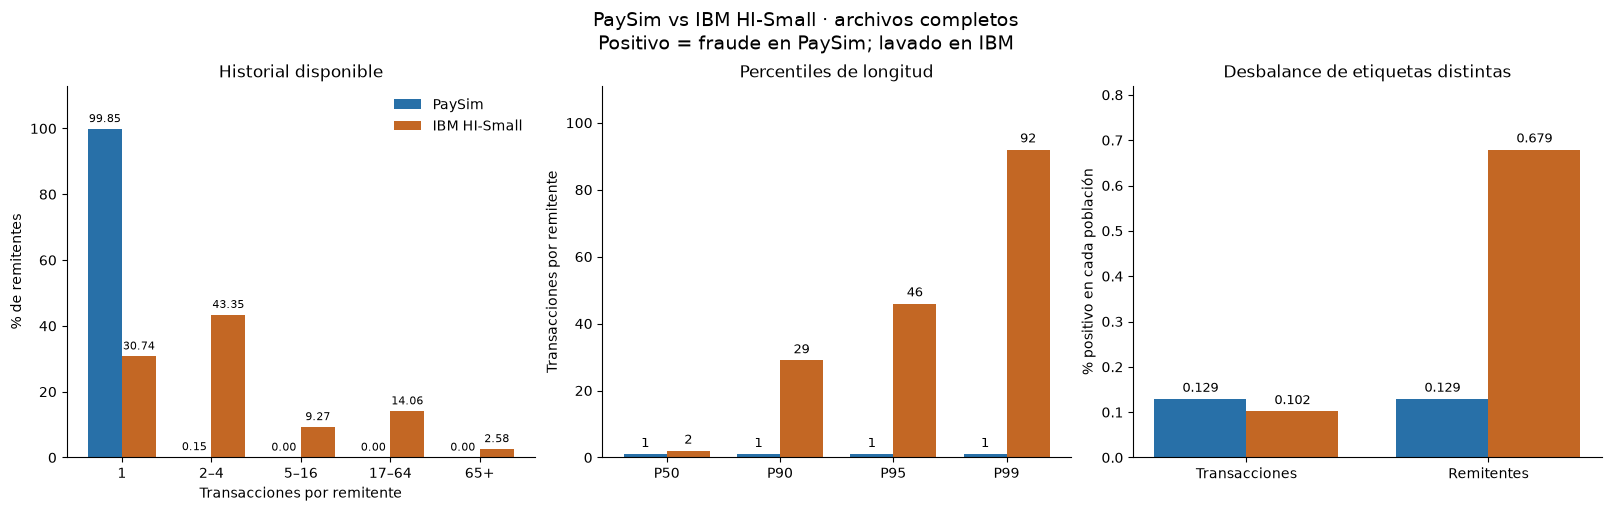

In [4]:
import matplotlib.pyplot as plt
figures = create_figures(result)
# Cerrar el registro automático evita mostrar el recorte antes de su sección.
for figure in figures.values():
    plt.close(figure)
display(figures["comparacion_datasets"])

## 5. Efecto de conservar las últimas 64 transacciones
Antes y después corresponden a **los mismos remitentes seleccionados**. Un historial puede perder su etiqueta positiva al descartar la única operación etiquetada. No sería correcto conservar esa etiqueta como si el modelo pudiera ver la operación eliminada.

| Medición | Antes | Después |
|---|---:|---:|
| Remitentes | 50,000 | 50,000 |
| Transacciones | 464,009 | 426,244 |
| Remitentes positivos | 366 | 362 |
| Transacciones positivas | 533 | 525 |
| Secuencias de longitud uno | 15,443 | 15,443 |

Historiales recortados: 1,307 (2.614%)
Positivos después del recorte: 0.724% de remitentes


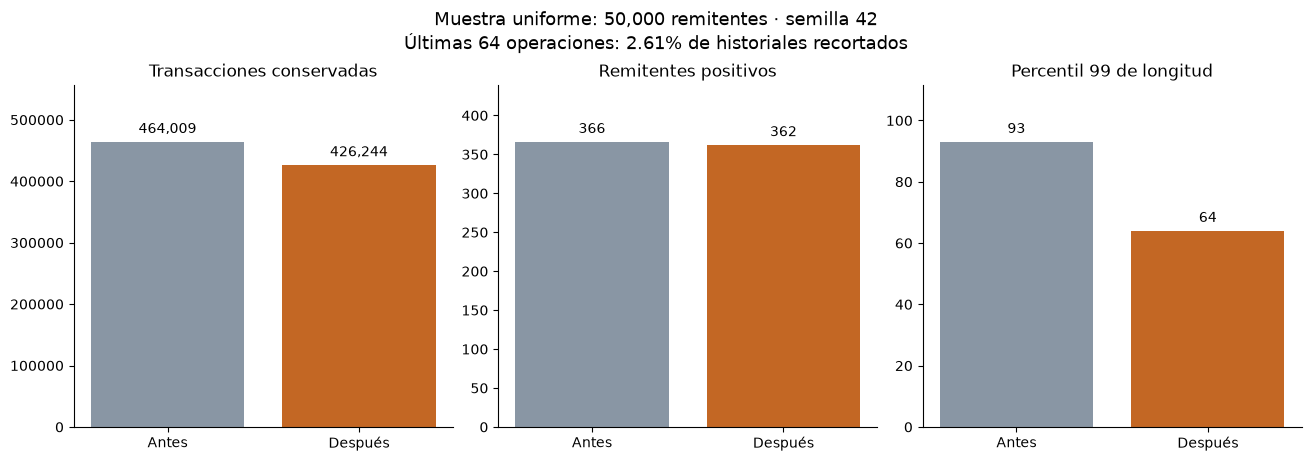

In [5]:
sample = result["sample"]
metrics = [
    ("Remitentes", sample["sample_senders"], sample["sample_senders"]),
    ("Transacciones", sample["full_transactions"], sample["retained_transactions"]),
    ("Remitentes positivos", sample["positive_senders_full"], sample["positive_senders_retained"]),
    ("Transacciones positivas", sample["positive_transactions_full"], sample["positive_transactions_retained"]),
    ("Secuencias de longitud uno", sample["before"]["singleton_senders"], sample["after"]["singleton_senders"]),
]
lines = ["| Medición | Antes | Después |", "|---|---:|---:|"]
lines += [f"| {name} | {before:,} | {after:,} |" for name, before, after in metrics]
display(Markdown("\n".join(lines)))
print(f"Historiales recortados: {sample['truncated_senders']:,} ({sample['truncated_sender_pct']:.3f}%)")
print(f"Positivos después del recorte: {sample['positive_sender_pct_retained']:.3f}% de remitentes")
display(figures["efecto_recorte"])
plt.close(figures["efecto_recorte"])

## 6. Integridad y trazabilidad
Estas comprobaciones verifican consistencia de conteos. Las pruebas con historiales desordenados, timestamps empatados y etiquetas descartadas están en `tests/test_compare_datasets.py`.

Cambiar los CSV, semilla, muestra o longitud puede cambiar los resultados. Los tiempos dependen de la computadora; no equivalen al tiempo de entrenamiento en Colab.

In [6]:
for dataset in result["datasets"]:
    hist = {int(length): count for length, count in dataset["length_histogram"].items()}
    assert sum(hist.values()) == dataset["senders"]
    assert sum(length * count for length, count in hist.items()) == dataset["rows"]
    assert 0 <= dataset["positive_senders"] <= dataset["senders"]
assert sample["retained_transactions"] <= sample["full_transactions"]
assert sample["positive_senders_retained"] <= sample["positive_senders_full"]
assert max(map(int, sample["after"]["length_histogram"])) <= MAX_LEN
print("Comprobaciones de consistencia: OK")
print(json.dumps({"python_version": result["python_version"], "sources": result["sources"], "selected_sender_keys_sha256": sample["selected_sender_keys_sha256"]}, indent=2))

Comprobaciones de consistencia: OK
{
  "python_version": "3.13.7",
  "sources": [
    {
      "name": "paysim.csv",
      "bytes": 493534783,
      "sha256": "16910f90577b0d981bf8ff289714510bb89bc71bff7d3f220f024e287e4eea6b"
    },
    {
      "name": "HI-Small_Trans.csv",
      "bytes": 475664283,
      "sha256": "b19d39f515523373f991b689c07e11e7b0b95c17a2c27a87d91584ae16c5b040"
    }
  ],
  "selected_sender_keys_sha256": "5d92255ce0b64f9a9854362850413a725235c9f4490375e89c3da2136b0ec0e6"
}


## 7. Interpretación y límites
- PaySim ofrece muy pocos historiales repetidos por remitente; las cifras anteriores justifican esa limitación sin inventar agrupaciones.
- IBM proporciona más secuencias con múltiples operaciones, pero todavía incluye muchos remitentes con una sola transacción y tiene fuerte desbalance.
- La muestra es uniforme por remitente, no por transacción. El recorte limita memoria y cómputo y puede eliminar evidencia positiva; reportamos ese efecto.
- Estos resultados no prueban utilidad predictiva ni cumplimiento regulatorio. Los datos son sintéticos y no representan directamente remesas guatemaltecas.
- El siguiente paso del plan es implementar C1 y sus splits; no se han creado en este análisis.



## 8. Comparación ampliada: seis variantes IBM
La elección inicial de HI-Small no era una comparación contra Medium y Large. Esta sección incluye **todos los CSV Trans y Accounts** de HI/LI y Small/Medium/Large.

HI y LI representan escenarios con mayor y menor proporción ilícita según el [paper original de IBM, NeurIPS 2023](https://proceedings.nips.cc/paper_files/paper/2023/file/5f38404edff6f3f642d6fa5892479c42-Paper-Datasets_and_Benchmarks.pdf). Los conteos aquí proceden de los archivos locales, no del artículo.

El proceso lee cada variante completa y guarda un JSON. Una ejecución posterior utiliza esos resultados si coinciden código, versión de Python, ruta, tamaño y fecha de modificación. `REFRESH_VARIANTS = True` fuerza una lectura completa y nueva huella SHA-256. **Los archivos Large tienen unos 17 GB cada uno:** esta auditoría exploratoria no forma parte de cada entrenamiento ni mide el tiempo de Colab.

In [7]:
from scripts.compare_ibm_variants import (
    VARIANTS, run_variants, save_variant_outputs, variants_markdown, create_variant_figures
)

REFRESH_VARIANTS = False
VARIANT_OUTPUT = ROOT / "reports" / "ibm_variants"
variant_results = run_variants(ROOT / "datasets" / "IBM", VARIANT_OUTPUT, refresh=REFRESH_VARIANTS)
save_variant_outputs(variant_results, VARIANT_OUTPUT)
display(Markdown(variants_markdown(variant_results)))

Reutilizando perfil completo guardado: HI-Small


Reutilizando perfil completo guardado: LI-Small


Reutilizando perfil completo guardado: HI-Medium


Reutilizando perfil completo guardado: LI-Medium


Reutilizando perfil completo guardado: HI-Large


Reutilizando perfil completo guardado: LI-Large


| Variante | Transacciones | Remitentes | % trans. positivas | P95 longitud | Entidades multicuentas |
|---|---:|---:|---:|---:|---:|
| HI-Small | 5,078,345 | 496,999 | 0.1019 | 46 | 63,518 |
| LI-Small | 6,924,049 | 681,283 | 0.0515 | 46 | 79,583 |
| HI-Medium | 31,898,238 | 2,013,639 | 0.1104 | 74 | 210,275 |
| LI-Medium | 31,251,483 | 1,969,967 | 0.0513 | 74 | 199,366 |
| HI-Large | 179,702,229 | 2,076,301 | 0.1255 | 426 | 212,235 |
| LI-Large | 176,066,557 | 2,031,710 | 0.0571 | 428 | 201,562 |

Entidades multicuentas: catálogo completo, no solo cuentas emisoras. Variantes analizadas por separado; no son splits de entrenamiento/prueba.

### Volumen, historial, desbalance y costo
Comparar transacciones positivas usa como denominador todas las transacciones de **cada variante**. El P95 describe la longitud por cuenta emisora. El tiempo incluye perfilado y cruce con Accounts, excluye el cálculo de hash y no representa entrenamiento.

Las variantes se analizan por separado. No se han usado Small, Medium y Large como splits, ni se ha demostrado que sean independientes entre sí.

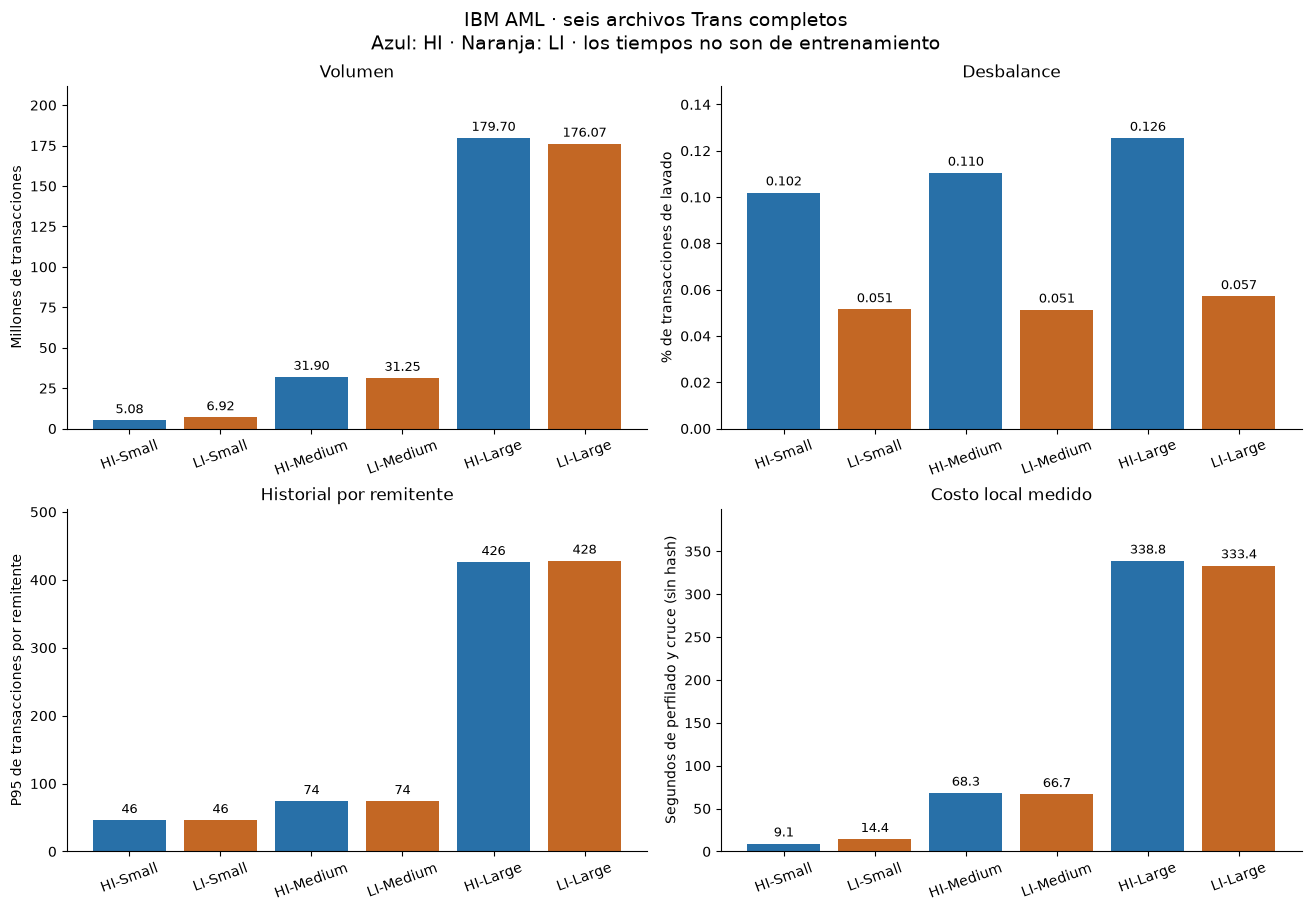

In [8]:
variant_figures = create_variant_figures(variant_results)
for figure in variant_figures.values():
    plt.close(figure)
display(variant_figures["variantes_ibm"])

## 9. Accounts: identidad y cobertura de la unión
Accounts describe cuentas y entidades; no agrega transacciones. La unión usa `(banco normalizado, cuenta)`. Para el banco, `03208` y `3208` se consideran la misma clave numérica. **Las cuentas y Entity ID permanecen como cadenas sin quitar ceros.**

Comparar el cruce literal con el normalizado permite detectar errores silenciosos. Una clave del catálogo que apunta a entidades contradictorias se informa como ambigua y no se asigna. Se informa también la cobertura para destinatarios.

En esta tabla las coberturas se ponderan por transacciones, no por cantidad de cuentas.

In [9]:
join_lines = [
    "| Variante | Cuentas Accounts | Origen literal (%) | Origen normalizado (%) | Destino normalizado (%) | Claves ambiguas |",
    "|---|---:|---:|---:|---:|---:|",
]
for profile in variant_results:
    origin, destination = profile["origin_join"], profile["destination_join"]
    literal_pct = 100 * origin["matched_transactions_literal"] / profile["rows"]
    join_lines.append(
        f"| {profile['variant']} | {profile['accounts']['rows']:,} | {literal_pct:.2f} | "
        f"{origin['transaction_coverage_pct']:.2f} | {destination['transaction_coverage_pct']:.2f} | "
        f"{profile['accounts']['ambiguous_keys']:,} |"
    )
display(Markdown("\n".join(join_lines)))

| Variante | Cuentas Accounts | Origen literal (%) | Origen normalizado (%) | Destino normalizado (%) | Claves ambiguas |
|---|---:|---:|---:|---:|---:|
| HI-Small | 518,581 | 0.00 | 100.00 | 100.00 | 0 |
| LI-Small | 712,688 | 0.00 | 100.00 | 100.00 | 0 |
| HI-Medium | 2,087,786 | 0.00 | 100.00 | 100.00 | 0 |
| LI-Medium | 2,040,823 | 0.00 | 100.00 | 100.00 | 0 |
| HI-Large | 2,126,855 | 0.00 | 100.00 | 100.00 | 0 |
| LI-Large | 2,079,627 | 0.00 | 100.00 | 100.00 | 0 |

## 10. Entidades con varias cuentas y consecuencias para los splits
El primer panel cuenta entidades multicuentas del catálogo completo. El segundo mide qué proporción de cuentas emisoras con cruce válido pertenece a entidades con **más de una cuenta emisora observada**.

Estas cifras muestran vínculos entre cuentas; **no miden fuga efectiva en un split**, porque todavía no se han creado las particiones. Separar por cuenta puede dejar cuentas de una misma entidad en conjuntos distintos. Una opción a evaluar en C1 es agrupar por `Entity ID` al dividir los datos y conservar las secuencias por cuenta. Eso puede cambiar tamaños y balance exactos de los conjuntos.

Los nombres y Entity ID se utilizan aquí como metadatos de auditoría, no como features.

| Variante | Entidades del catálogo | Entidades multicuentas | Entidades con varias cuentas emisoras |
|---|---:|---:|---:|
| HI-Small | 166,207 | 63,518 | 61,892 |
| LI-Small | 224,931 | 79,583 | 77,837 |
| HI-Medium | 668,138 | 210,275 | 206,207 |
| LI-Medium | 654,133 | 199,366 | 195,525 |
| HI-Large | 670,231 | 212,235 | 209,402 |
| LI-Large | 656,221 | 201,562 | 198,810 |

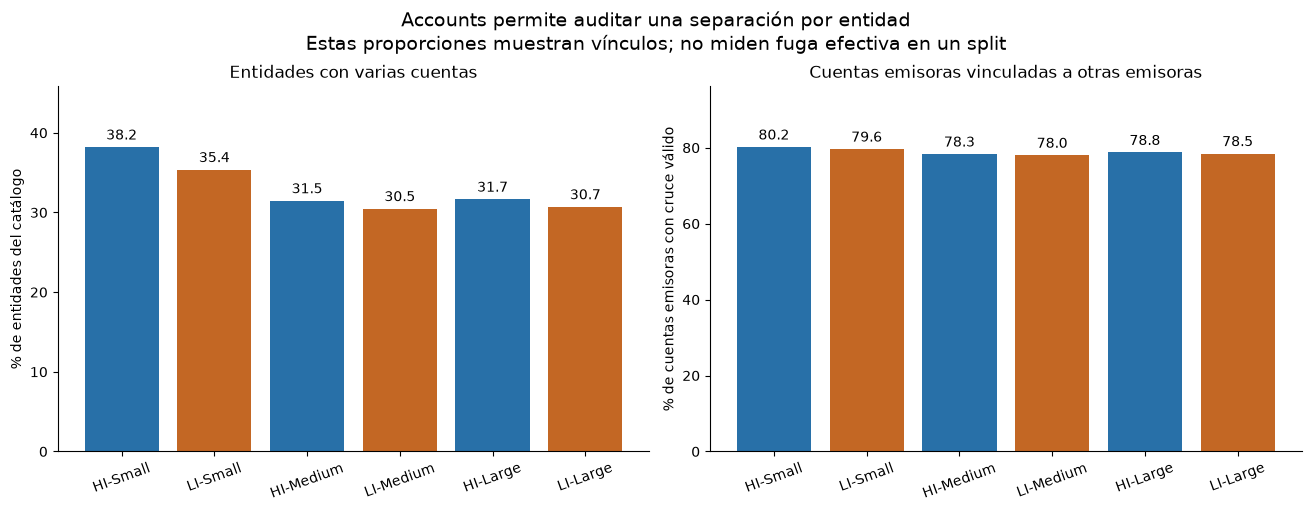

In [10]:
entity_lines = [
    "| Variante | Entidades del catálogo | Entidades multicuentas | Entidades con varias cuentas emisoras |",
    "|---|---:|---:|---:|",
]
for profile in variant_results:
    catalog, origin = profile["accounts"], profile["origin_join"]
    entity_lines.append(
        f"| {profile['variant']} | {catalog['entities']:,} | {catalog['entities_multiple_accounts']:,} | "
        f"{origin['active_entities_multiple_sending_accounts']:,} |"
    )
display(Markdown("\n".join(entity_lines)))
display(variant_figures["entidades_multicuentas"])

## 11. Consistencia, límites y decisión pendiente
El recorte de la muestra inicial sigue correspondiendo a HI-Small. Para las otras variantes se compara el número de historiales largos, pero **no se inventan etiquetas después del recorte** ni se extrapolan los 362 positivos de la muestra inicial.

Un dataset mayor puede aportar más historiales y positivos, pero esa ventaja debe contrastarse con resultados de modelos y tiempos de reproducción. Esta ampliación no modifica automáticamente la selección del dataset ni los splits del plan.

Los archivos Patterns describen patrones etiquetados del generador. Quedan para el análisis posterior de casos y no se incorporan como entradas del modelo.

In [11]:
assert tuple(profile["variant"] for profile in variant_results) == VARIANTS
for profile in variant_results:
    histogram = {int(k): v for k,v in profile["length_histogram"].items()}
    assert sum(histogram.values()) == profile["senders"]
    assert sum(length * count for length, count in histogram.items()) == profile["rows"]
    assert profile["transactions_retainable_at_64"] <= profile["rows"]
    assert profile["accounts"]["entities_multiple_accounts"] <= profile["accounts"]["entities"]
    for endpoint in ("origin_join", "destination_join"):
        audit = profile[endpoint]
        assert audit["matched_transactions_literal"] <= audit["matched_transactions_normalized"] <= profile["rows"]
        assert audit["matched_accounts_normalized"] + audit["unmatched_accounts"] == audit["observed_accounts"]
    assert all(len(source["sha256"]) == 64 for source in profile["sources"])
print("Seis variantes completas: histogramas, coberturas y huellas consistentes.")
print("El detalle y las huellas de cada archivo están en reports/ibm_variants/<variante>.json.")

Seis variantes completas: histogramas, coberturas y huellas consistentes.
El detalle y las huellas de cada archivo están en reports/ibm_variants/<variante>.json.


### Lectura de los resultados obtenidos
Las siguientes observaciones se construyen con los perfiles calculados. Ayudan a justificar el tamaño de dataset y la política de longitud; no sustituyen los experimentos de los modelos.

In [12]:
by_variant = {profile["variant"]: profile for profile in variant_results}
hi_small, hi_medium, hi_large = [by_variant[f"HI-{size}"] for size in ("Small", "Medium", "Large")]
observations = [
    f"- **Longitudes:** P95 de HI-Small = {hi_small['length_quantiles']['0.95']}; "
    f"HI-Medium = {hi_medium['length_quantiles']['0.95']}; HI-Large = {hi_large['length_quantiles']['0.95']}. "
    "Cambiar la fuente requiere revisar el límite de secuencia.",
    "- **Límite 64:** afectaría al " + ", ".join(
        f"{100 * profile['senders_over_64'] / profile['senders']:.2f}% de los historiales de {profile['variant']}"
        for profile in (hi_small, hi_medium, hi_large)
    ) + ". No implica que se pierda ese mismo porcentaje de casos positivos.",
    f"- **Entidades:** HI-Small tiene {hi_small['origin_join']['active_entities_multiple_sending_accounts']:,} "
    "entidades con varias cuentas emisoras observadas. Accounts aporta información para auditar la separación entre conjuntos.",
    "- **Elección inicial:** mantener HI-Small como punto de partida es una decisión de presupuesto de datos y experimentación. "
    "La comparación no prueba que obtenga mejores métricas que Medium o Large.",
]
display(Markdown("\n".join(observations)))

- **Longitudes:** P95 de HI-Small = 46; HI-Medium = 74; HI-Large = 426. Cambiar la fuente requiere revisar el límite de secuencia.
- **Límite 64:** afectaría al 2.58% de los historiales de HI-Small, 6.45% de los historiales de HI-Medium, 21.75% de los historiales de HI-Large. No implica que se pierda ese mismo porcentaje de casos positivos.
- **Entidades:** HI-Small tiene 61,892 entidades con varias cuentas emisoras observadas. Accounts aporta información para auditar la separación entre conjuntos.
- **Elección inicial:** mantener HI-Small como punto de partida es una decisión de presupuesto de datos y experimentación. La comparación no prueba que obtenga mejores métricas que Medium o Large.